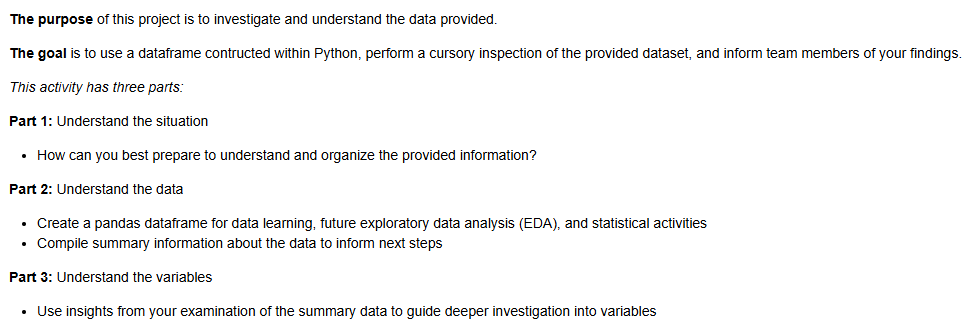

In [1]:
import numpy as np
import pandas as pd

In [2]:
df_waze = pd.read_csv('waze_dataset.csv')

# Summary information

In [3]:
df_waze.head(10)

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android
5,5,retained,113,103,279.544437,2637,0,0,901.238699,439.101397,15,11,iPhone
6,6,retained,3,2,236.725314,360,185,18,5249.172828,726.577205,28,23,iPhone
7,7,retained,39,35,176.072845,2999,0,0,7892.052468,2466.981741,22,20,iPhone
8,8,retained,57,46,183.532018,424,0,26,2651.709764,1594.342984,25,20,Android
9,9,churned,84,68,244.802115,2997,72,0,6043.460295,2341.838528,7,3,iPhone


In [4]:
df_waze.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


# Null values and summary statistics

In [5]:
# Isolate rows with null values
### YOUR CODE HERE ###
df_null_rows = df_waze[df_waze.isnull().any(axis=1)]

# Display summary stats of rows with null values
### YOUR CODE HERE ###
df_null_rows.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,7405.584286,80.837143,67.798571,198.483348,1709.295714,118.717143,30.371429,3935.967029,1795.123358,15.382857,12.125714
std,4306.900234,79.987440,65.271926,140.561715,1005.306562,156.308140,46.306984,2443.107121,1419.242246,8.772714,7.626373
min,77.000000,0.000000,0.000000,5.582648,16.000000,0.000000,0.000000,290.119811,66.588493,0.000000,0.000000
25%,3744.500000,23.000000,20.000000,94.056340,869.000000,4.000000,0.000000,2119.344818,779.009271,8.000000,6.000000
50%,7443.000000,56.000000,47.500000,177.255925,1650.500000,62.500000,10.000000,3421.156721,1414.966279,15.000000,12.000000
75%,11007.000000,112.250000,94.000000,266.058022,2508.750000,169.250000,43.000000,5166.097373,2443.955404,23.000000,18.000000
max,14993.000000,556.000000,445.000000,1076.879741,3498.000000,1096.000000,352.000000,15135.391280,9746.253023,31.000000,30.000000


In [6]:
# Isolate rows without null values
### YOUR CODE HERE ###
df_non_null_rows = df_waze.dropna()

# Display summary stats of rows without null values
### YOUR CODE HERE ###
df_non_null_rows.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,7503.573117,80.623820,67.255822,189.547409,1751.822505,121.747395,29.638296,4044.401535,1864.199794,15.544653,12.182530
std,4331.207621,80.736502,65.947295,136.189764,1008.663834,147.713428,45.350890,2504.977970,1448.005047,9.016088,7.833835
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000
50%,7504.000000,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000
75%,11257.500000,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


#  Null values - device counts

In [8]:
# Get count of null values by device
### YOUR CODE HERE ###
null_counts_by_device = df_waze.groupby('device').apply(lambda x: x.isnull().sum())
null_counts_by_device

C:\Users\space\AppData\Local\Temp\ipykernel_12520\2674248714.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  null_counts_by_device = df_waze.groupby('device').apply(lambda x: x.isnull().sum())


,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
device,,,,,,,,,,,,,
Android,0,253,0,0,0,0,0,0,0,0,0,0,0
iPhone,0,447,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Calculate % of iPhone nulls and Android nulls
### YOUR CODE HERE ###
print(f'The percentage of null values for each device is: \n{round(df_null_rows["device"].value_counts(normalize=True) * 100, 2)}')

The percentage of null values for each device is:
device
iPhone     63.86
Android    36.14
Name: proportion, dtype: float64


In [49]:
print(f'The percentage of users for each device is: \n{round(df_waze["device"].value_counts(normalize=True) * 100, 2)}')

The percentage of users for each device is: 
device
iPhone     64.48
Android    35.52
Name: proportion, dtype: float64


In [27]:
# Calculate counts of churned vs. retained
# 1. Conteo absoluto de cada grupo
churn_counts = df_waze['label'].value_counts()
print("Absolute Counts :\n", churn_counts)

# 2. Porcentajes (proporciones)
churn_percentages = round(df_waze['label'].value_counts(normalize=True) * 100, 0)
print("\nPercentages:\n", churn_percentages)

Absolute Counts :
 label
retained    11763
churned      2536
Name: count, dtype: int64

Percentages:
 label
retained    82.0
churned     18.0
Name: proportion, dtype: float64


In [33]:
# Calculate median values of all columns for churned and retained users
df_waze.groupby('label').median(numeric_only=True)

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
label,,,,,,,,,,,
churned,7477.5,59.0,50.0,164.339042,1321.0,84.5,11.0,3652.655666,1607.183785,8.0,6.0
retained,7509.0,56.0,47.0,157.586756,1843.0,68.0,9.0,3464.684614,1458.046141,17.0,14.0


In [35]:
# Add a column to df called `km_per_drive`
### YOUR CODE HERE ###
df_waze['km_per_drive'] = df_waze['driven_km_drives'] / df_waze['drives']

# Group by `label`, calculate the median, and isolate for km per drive
### YOUR CODE HERE ###
df_waze.groupby('label')['km_per_drive'].median()

label
churned     74.109416
retained    75.014702
Name: km_per_drive, dtype: float64

In [ ]:

df_waze['km_per_driving_day'] = df_waze['driven_km_drives'] / df_waze['driving_days']
# Group by `label`, calculate the median, and isolate for km per driving day
df_waze.groupby('label')['km_per_driving_day'].median()

label
churned     697.541999
retained    289.549333
Name: km_per_driving_day, dtype: float64

In [38]:
df_waze['drives_per_driving_day'] = df_waze['drives'] / df_waze['driving_days']
# Group by `label`, calculate the median, and isolate for drives per driving day
df_waze.groupby('label')['drives_per_driving_day'].median()

label
churned     10.0000
retained     4.0625
Name: drives_per_driving_day, dtype: float64

In [51]:
# For each label, calculate the number of Android users and iPhone users
### YOUR CODE HERE ###

df_waze.groupby(['label', 'device']).size()

label     device 
churned   Android     891
          iPhone     1645
retained  Android    4183
          iPhone     7580
dtype: int64

In [45]:
# For each label, calculate the percentage of Android users and iPhone users
### YOUR CODE HERE ###
device_percentages_by_label = df_waze.groupby('label')['device'].value_counts(normalize=True) * 100
print(f'The percentage of Android users and iPhone users for each label is:\n{round(device_percentages_by_label,2)}')

The percentage of Android users and iPhone users for each label is:
label     device 
churned   iPhone     64.87
          Android    35.13
retained  iPhone     64.44
          Android    35.56
Name: proportion, dtype: float64


# Conclusion

Questions:

1. Did the data contain any missing values? How many, and which variables were affected? Was there a pattern to the missing data?
- The dataset has 700 missing values in the label column. There was no obvious pattern to the missing values.

2. What is a benefit of using the median value of a sample instead of the mean?
- Mean is subject to the influence of outliers, while the median represents the middle value of the distribution regardless of any outlying values.

3. Did your investigation give rise to further questions that you would like to explore or ask the Waze team about?
- Yes. For example, the median user who churned drove 698 kilometers each day they drove last month, which is about 240% the per-drive-day distance of retained users. It would be helpful to know how this data was collected and if it represents a non-random sample of users.

4. What percentage of the users in the dataset were Android users and what percentage were iPhone users?
- Android users comprised approximately 36% of the sample, while iPhone users made up about 64%

5. What were some distinguishing characteristics of users who churned vs. users who were retained?
- Generally, users who churned drove farther and longer in fewer days than retained users. They also used the app about half as many times as retained users over the same period.

6. Was there an appreciable difference in churn rate between iPhone users vs. Android users?
- No. The churn rate for both iPhone and Android users was within one percentage point of each other. There is nothing suggestive of churn being correlated with device.